# Testing a new-physics model with PTArcade

You have been handed a **free spectrum**: the amplitude of the common red noise in each of
14 frequency bins, measured from a 16-year simulated PTA dataset with no assumption about
where the signal came from. It lives in `ceffyl-freespec/`, compressed into a `ceffyl` KDE.

Now we ask a physics question: **could this signal have come from a cosmological
first-order phase transition?**

PTArcade is built for exactly this. You give it two files:

1. a **model file** saying what spectrum your new physics predicts, and
2. a **config file** saying what data to fit and how to run.

It then runs the MCMC for you. Because it fits the compressed free spectrum rather than
the 67 pulsars directly, a fit takes minutes instead of hours.

**You are going to write both files yourself.** Cells marked `TODO` are yours to fill in;
everything else is given. The cosmology boilerplate and the fitted constants from the
bubble-collision simulations are handed to you, since the point of this exercise is the
PTArcade interface and the physics choices rather than typing out long formulae.

> These data are simulated, so there is a right answer. Checking whether you recovered it
> is something you never get to do with real data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# The values the signal was injected with, from simulate-data.ipynb.
PAR_NAMES = ["log10_alpha", "log10_T_star", "log10_H_R", "a", "b", "c"]
TRUTHS = dict(zip(PAR_NAMES, (0.74, -0.89, -0.2, 2.5, 2, 1.2)))

freqs = np.load("../ceffyl-freespec/freqs.npy")
print(f"The free spectrum covers {len(freqs)} frequencies:")
print(f"{freqs[0]:.3e} Hz to {freqs[-1]:.3e} Hz")

The free spectrum covers 14 frequencies:
1.977e-09 Hz to 2.768e-08 Hz


# Step 1: Write the model file

A PTArcade model file is an ordinary Python file. At minimum it needs two things.

**`parameters`**, a dictionary mapping parameter names to priors, built with the
`prior` helper from `ptarcade.models_utils`:

```python
parameters = {'a': prior("Uniform", 0, 1), 'b': prior("Uniform", 0, 1)}
```

**`spectrum(f, ...)`**, a function whose first argument `f` is a NumPy array of
frequencies in Hz, whose remaining arguments have *exactly* the names used as keys in
`parameters`, and which returns $h^2\Omega_{\rm gw}$ at each frequency:

```python
def spectrum(f, a, b):
    return a / (1 + b / f)
```

Two optional extras are worth setting:

- **`name`** labels the output directory (default `"np_model"`)
- **`smbhb`**, if `True`, adds the expected supermassive black hole binary background on
  top of your signal. We leave it `False` so we fit the phase transition alone.

Beyond that it is just Python: import what you like, define helper functions, interpolate
tabulated data.

### The physics of our signal

When bubbles of a new vacuum nucleate, expand and collide, the collisions radiate gravitational waves.
The spectrum is a broken power law: rising as $f^{a}$ below a peak, falling as $f^{-b}$ above it, with $c$ setting how sharp the turnover is.
Written as a function of $x = f/f_{\rm peak}$, the shape is

$$S(x) = \frac{(a+b)^{c}}{\left(b\,x^{-a/c} + a\,x^{b/c}\right)^{c}},$$

which you will implement below.

Three physical parameters fix the amplitude and where that peak lands today:

| parameter | meaning |
|---|---|
| $\alpha$ | strength. Energy released, relative to the radiation bath |
| $T_*$ | temperature of the Universe when it happened (GeV) |
| $H_*R$ | bubble size at collision, in units of the Hubble radius |

$T_*$ matters because gravitational waves redshift, and there's a "tug-of-war" going on between redshifting and the initial frequency that also depends on $T_*$.
A transition at higher temperature happened earlier, so its waves have been stretched more but were also emitted at higher frequencies.
Together, the peak frequency today ends up being proportional to $T_*$.
Landing in the PTA band ($\sim$nHz) needs $T_* \sim 0.1$ GeV, which is right around the QCD phase transition! 

`ptarcade.models_utils` supplies the cosmology: `g_s` and `g_rho` (relativistic degrees of freedom), `T_0`, `T_eq`, `M_pl`, `H_0`, `h`, and the `gev_to_hz` conversion.

### Priors
For this search, we'll use the following priors (you'll need to fill them in)
| parameter | prior |
|---|---|
| $\log_{10}\alpha$ | U(-2, 1) |
| $\log_{10}T_*$ | U(-4,4) |
| $\log_{10}H_*R$ | U(-3, 0)|
| $a$ | U(1, 3)|
| $b$ | U(1, 3)|
| $c$ | U(1, 3)|

Complete the model file below. Running the cell below writes the file to disk.


In [2]:
%%writefile pt_bubble_model.py
"""Gravitational waves from bubble collisions in a first-order phase transition."""
import numpy as np
from scipy.special import gamma

import ptarcade.models_utils as aux
from ptarcade.models_utils import prior

name = "pt_bubble"   # names the output directory
smbhb = False        # don't add the black hole binary background

parameters = {
    "log10_alpha": prior("Uniform", -2, 1),    # transition strength
    "log10_T_star": prior("Uniform", -4, 4),   # temperature / GeV
    "log10_H_R": prior("Uniform", -3, 0),      # bubble size / Hubble radius
    "a": prior("Uniform", 1, 3),               # low-frequency slope
    "b": prior("Uniform", 1, 3),               # high-frequency slope
    "c": prior("Uniform", 1, 3),               # sharpness of the peak
}


def S(x, a, b, c):
    """Spectral shape vs x = f / f_peak: rises as x^a, falls as x^-b."""
    return (a + b) ** c / (b * x ** (-a / c) + a * x ** (b / c)) ** c


def spectrum(f, log10_alpha, log10_T_star, log10_H_R, a, b, c):
    """Return h^2 Omega_gw at each frequency in f [Hz]."""
    alpha = 10**log10_alpha
    T_star = 10**log10_T_star
    H_R = 10**log10_H_R

    H_beta = H_R * (8 * np.pi) ** (-1 / 3)   # Hubble rate / transition rate

    # numbers from the bubble-collision simulations of 1605.01403
    delta = 0.48 / (1 + 5.3 + 5)             # efficiency of converting energy to GWs
    f_peak = 0.35 / (1 + 0.69 + 0.069)       # peak frequency at emission
    p, q, kappa = 2, 2, 1

    # relativistic degrees of freedom: at matter-radiation equality, and at emission
    g_s_eq = aux.g_s(aux.T_eq)
    g_s_star = aux.g_s(T_star)
    g_star = aux.g_rho(T_star)

    # normalise S so its peak value is 1
    n = (a + b) / c
    norm = ((b / a) ** (a / n) * (n * c / b) ** c
            * gamma(a / n) * gamma(b / n) / (n * gamma(c)))

    # redshifting of the GW energy density from emission until today
    dil = (np.pi**2 / 90 * g_star * (g_s_eq / g_s_star) ** (4 / 3)
           * aux.T_0**4 / (aux.M_pl * aux.H_0) ** 2)

    # peak frequency today, in Hz
    f_0 = (90 ** (-1 / 2) * np.pi * g_star ** (1 / 2) * (g_s_eq / g_s_star) ** (1 / 3)
           * aux.T_0 / aux.M_pl * T_star * f_peak * H_beta**-1 * aux.gev_to_hz)

    return (1 / norm * aux.h**2 * dil * delta * H_beta**q
            * (kappa * alpha / (1 + alpha)) ** p * S(f / f_0, a, b, c))

Overwriting pt_bubble_model.py


### Check the model before you run

Always plot a model spectrum before handing it to a sampler (a sort-of prior-predictive check).
A typo that returns zeros, or lands ten orders of magnitude off, is far easier to catch here than in a chain that fails three days later.

The grey band is the frequency range our data actually covers.
Notice how the peak slides *right* as $T_*$ goes up.

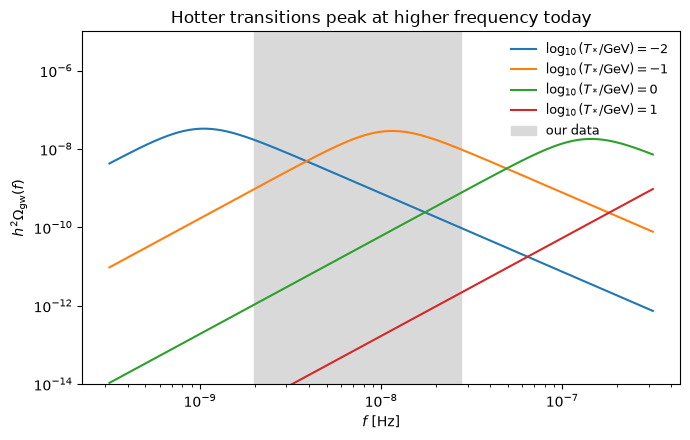

In [3]:
import pt_bubble_model

f_grid = np.logspace(-9.5, -6.5, 300)

fig, ax = plt.subplots(figsize=(7, 4.5))
for log10_T in [-2, -1, 0, 1]:
    omega = pt_bubble_model.spectrum(f_grid, 0.74, log10_T, -0.2, 2.5, 2.0, 1.2)
    ax.loglog(f_grid, omega, label=rf"$\log_{{10}}(T_*/\mathrm{{GeV}}) = {log10_T}$")

ax.axvspan(freqs[0], freqs[-1], color="0.85", zorder=0, label="our data")
ax.set_xlabel("$f$ [Hz]")
ax.set_ylabel(r"$h^2\Omega_{\rm gw}(f)$")
ax.set_ylim(1e-14, 1e-5)
ax.legend(frameon=False, fontsize=9)
ax.set_title("Hotter transitions peak at higher frequency today")
plt.tight_layout()

# Step 2: Write the config file

The config file controls the run: which data, how long to sample, where output goes.
PTArcade ships a default that is a good starting point.

In [4]:
from importlib.resources import files

print(files("ptarcade.data").joinpath("default_config.py").read_text())

pta_data = 'NG15' # PTA dataset to use in the analysis, available options are NG15, NG12, IPTA2

mode = 'ceffyl'

mod_sel = False # set to True if you want to compare the new-physics signal to the SMBHB signal

out_dir = './chains/'
resume = False
N_samples = int(2e6) # number of sample points for the mcmc

# intrinsic red noises parameters
red_components = 30 # number of frequency components for the intrinsic red noise

# bhbh signal parameters
corr = False # set to True if you want to include HD spatial correlations in the analysis 
gwb_components = 14 # number of frequency components for common process
bhb_th_prior = True # if set to True the prior for the bhb signal is set to a theory  motivated 2d gaussian
A_bhb_logmin = None # lower limit for the prior of the bhb signal amplitude. If set to None -18 is used
A_bhb_logmax = None # upper limit for the prior of the bhb signal amplitude. If set to None -14 is used
gamma_bhb = None # spectral index for the bhb singal. If set to None it

We only need to change three things:

| setting | default | ours | why |
|---|---|---|---|
| `pta_data` | `'NG15'` | a dictionary | we are fitting **our own** free spectrum, not a published dataset |
| `out_dir` | `'./chains/'` | `'./ptarcade_chains/'` | keep the tutorial directory tidy |
| `N_samples` | `int(2e6)` | `int(1e6)` | about 3 minutes; use 2e6 or more for a real result |

`pta_data` is the interesting one.
Normally, you name a published dataset and PTArcade downloads it from Zenodo or another archive.
To use your own data, supply a dictionary instead.
In `ceffyl` mode, the mode we're going to use, `psrs_data` is the path to a `ceffyl` density directory.
The other two keys apply only to `enterprise` mode, so they are `None`, but **all three keys must be present in this order**.

Everything else can stay at its default. 

In [5]:
%%writefile config.py
pta_data = {
    "psrs_data": "../ceffyl-freespec",
    "noise_data": None,
    "emp_dist": None,
}

mode = "ceffyl"      # fit the free spectrum rather than the pulsars directly

out_dir = "./ptarcade_chains/"
N_samples = int(1e6) # 3 minutes

Overwriting config.py


# Step 3: Run PTArcade

That is everything PTArcade needs.
It is meant as a command-line tool, so from a terminal you would type

```sh
ptarcade -m pt_bubble_model.py -c config.py -n 0
```

- `-m` your model file
- `-c` your config file
- `-n` a label for this chain, appended to `chain_` (handy when you run launch several on a cluster)

The `!` prefix below runs that exact command from the notebook.
If you would rather run it in a terminal, open a terminal in JupyterLab or wherever you'd like: it will not affect the rest of the tutorial.

This (should) take about three minutes.
On a cluster you could run parallel-tempering across cores with `mpirun -n 4 ptarcade -m pt_bubble_model.py -c config.py -n 0`, but let's not do that today.

In [6]:
!ptarcade -m pt_bubble_model.py -c config.py -n 0

╭─────────────────╮
│ Starting to run │
╰─────────────────╯

Node Information                                            
╭───────┬──────────────────────────────────────────────────╮
│ Node  │ CPU                                              │
├───────┼──────────────────────────────────────────────────┤
│ axion │ unknown CPU (for better info install py-cpuinfo) │
╰───────┴──────────────────────────────────────────────────╯

Done initializing PTA ✔

Done initializing Sampler ✔

Done with all initializtions.
Setup times (including first sample) 0.05 seconds real, 0.45 seconds CPU

Starting to sample 1000000 samples

Finished 1.00 percent (1.00 percent of new work) in 2.195004 s Acceptance rate = 0.1996Adding DE jump with weight 50
Finished 100.00 percent (100.00 percent of new work) in 188.329844 s Acceptance rate = 0.322247
Run Complete

╭───────────────╮
│ Done sampling │
╰───────────────╯

Run Summary                                                          
╭─────────────┬───────────

### What it produced

Output lands in `out_dir / name / chain_<n>` according to your config file, your model file, and the `-n` flag respectively.
Most of these files describe the sampler's internal state.
The two that matter to us today are **`pars.txt`** (parameter names, in the order they appear in the chain) and **`chain_1.txt`** (the samples).

In [7]:
chain_dir = Path("ptarcade_chains/pt_bubble/chain_0")
for f in sorted(chain_dir.iterdir()):
    print(f"{f.name}")

print("\npars.txt:")
print((chain_dir / "pars.txt").read_text())

DEJump_jump.txt
chain_1.txt
cov.npy
covarianceJumpProposalAM_jump.txt
covarianceJumpProposalSCAM_jump.txt
jumps.txt
pars.txt
priors.txt

pars.txt:
log10_alpha
log10_T_star
log10_H_R
a
b
c



# Step 4: Inspect the results

`chains_utils.import_chains` reads the chain, throws away a burn-in fraction, and returns the priors alongside the samples.
PTMCMCSampler already thinned by a factor of 10, so 1e6 samples gives 1e5 rows, and dropping 25% to burn-in leaves 75,000.

The last four columns are sampler diagnostics, not model parameters.

In [8]:
from ptarcade import chains_utils, plot_utils

params, chain = chains_utils.import_chains("ptarcade_chains/pt_bubble", burn_frac=0.25)
names = list(params)

print(f"{chain.shape[0]} samples, {chain.shape[1]} columns")
print("columns:", names)

Starting import from ptarcade_chains/pt_bubble
Finished importing   ptarcade_chains/pt_bubble in 0.14s
75001 samples, 10 columns
columns: ['log10_alpha', 'log10_T_star', 'log10_H_R', 'a', 'b', 'c', 'log_posterior', 'log_likelihood', 'acceptance_rate', 'n_parall']


### Did the chain converge?

Before trusting any posterior, look at the traces.
You want each parameter wandering over its range without sticking in one place for long stretches, and no overall drift.
If a trace looks like a staircase instead of a fuzzy caterpillar, the chain has not converged and you need more samples.

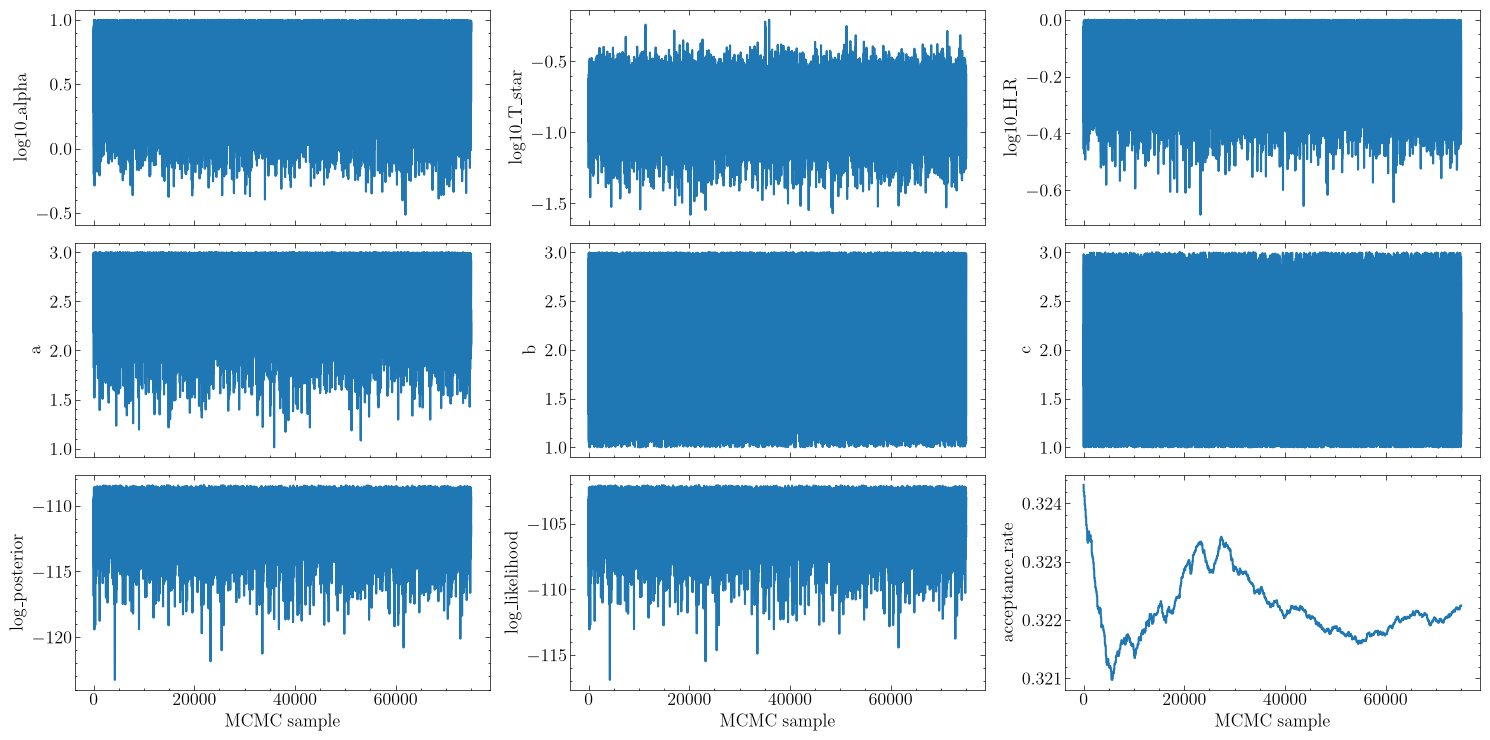

In [9]:
plot_utils.plot_chains(chain, names)

### The posteriors

`plot_posteriors` is PTArcade's built-in corner plot routine.
It's the same one used in the NANOGrav 15 yr new-physics papers.
`verbose=True` prints a statistical summary underneath showing the highest-posterior-density intervals, the posterior mean of each parameter, and the maximum a-posteriori point.

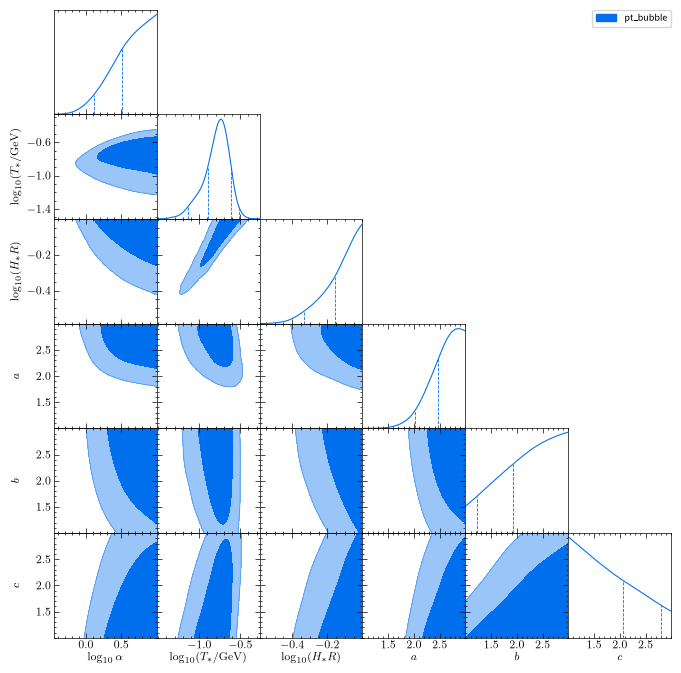

In [10]:
# These can be whatever you want
labels = [r"$\log_{10}\alpha$", r"$\log_{10}(T_*/\mathrm{GeV})$",
          r"$\log_{10}(H_*R)$", r"$a$", r"$b$", r"$c$"]

fig, axs = plot_utils.plot_posteriors(
    [chain], # needs list, can be multiple chains
    [params], # same here and below
    par_to_plot=[PAR_NAMES],
    par_names=[labels],
    samples_name=["pt_bubble"],
    hpi_levels=[0.68, 0.95],
    verbose=False,
    fig_width_pt=500
)

Several of those parameters are only bounded on one side.
The verbose summary reports limits that "do not exist", and the maximum-posterior point sits exactly on a prior edge.
That is normal when the data do not strongly constrain a parameter.
These posteriors are still useful in that they allow us to set **limits** on the parameters from one side.

### Did we recover the injection?

Let's overplot the injections onto the posteriors we plotted above.

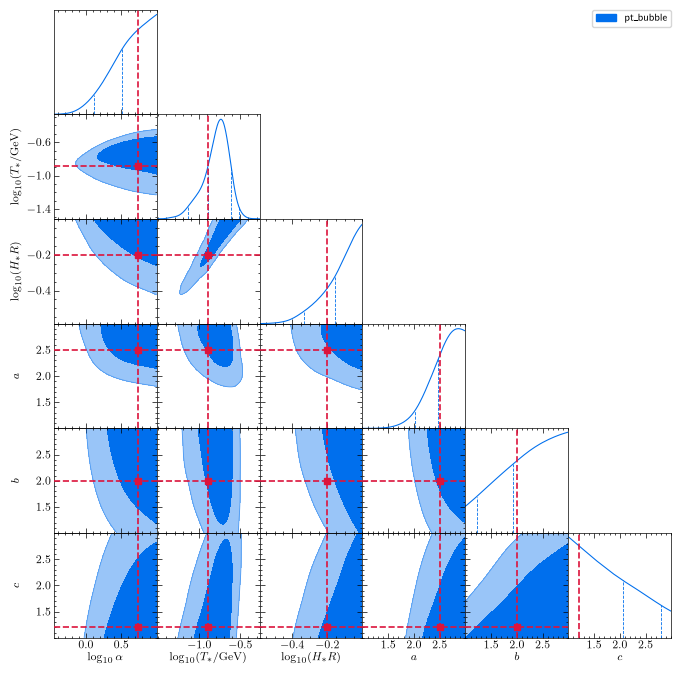

In [11]:
# These can be whatever you want
labels = [r"$\log_{10}\alpha$", r"$\log_{10}(T_*/\mathrm{GeV})$",
          r"$\log_{10}(H_*R)$", r"$a$", r"$b$", r"$c$"]

fig, axs = plot_utils.plot_posteriors(
    [chain], # needs list, can be multiple chains
    [params], # same here and below
    par_to_plot=[PAR_NAMES],
    par_names=[labels],
    samples_name=["pt_bubble"],
    hpi_levels=[0.68, 0.95],
    verbose=False,
    fig_width_pt=500
)
truth = [TRUTHS[p] for p in PAR_NAMES]

for ax in axs:
    ss = ax.get_subplotspec()
    row, col = ss.rowspan.start, ss.colspan.start
    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    ax.axvline(truth[col], color="crimson", ls="--", lw=1.2, zorder=5)
    if row != col:
        ax.axhline(truth[row], color="crimson", ls="--", lw=1.2, zorder=5)
        ax.plot(truth[col], truth[row], "s", ms=4.5, color="crimson", zorder=6)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

### Compare the fitted spectrum to the data

Hopefully, we recovered the injection within $\sim 1 \sigma$.
Another check we can do is whether the fitted spectrum passes through the free spectrum we measured.

We'll need to convert units to $\log_{10}\rho$, where $\rho$ is the amplitude of the timing residuals in a frequency bin, in seconds.
So we convert our model's $h^2\Omega$ into $\rho$ using the relation

$$\rho^2 = \frac{H_0^2\,\Omega_{\rm gw}}{8\pi^4 f^5\,T_{\rm span}}.$$

In [12]:
import la_forge.core as co
import ptarcade.models_utils as aux
from la_forge import rednoise
import pt_bubble_model

# The free-spectrum posterior as saved by curn-run.ipynb.
core = co.Core(corepath="../ceffyl-core/freespec.core")
core_freqs, n_rho = rednoise.get_rn_freqs(core)   # the frequencies stored in the core
Tspan = 1 / core_freqs[0]


def h2omega_to_log10rho(omega, f):
    """Convert a model h^2 Omega_gw into the free spectrum's log10(rho / s)."""
    rho2 = aux.H_0_Hz**2 * (omega / aux.h**2) / (8 * np.pi**4 * f**5 * Tspan)
    return 0.5 * np.log10(rho2)


def model_log10rho(f, pars):
    return h2omega_to_log10rho(pt_bubble_model.spectrum(f, *pars), f)


rng = np.random.default_rng(0)
draws = rng.choice(chain.shape[0], 400, replace=False)
f_plot = np.logspace(np.log10(freqs[0]) - 0.15, np.log10(freqs[-1]) + 0.15, 200)
curves = np.array([model_log10rho(f_plot, [chain[i, names.index(p)] for p in PAR_NAMES])
                   for i in draws])
lo, mid, hi = np.percentile(curves, [16, 50, 84], axis=0)
injected = model_log10rho(f_plot, [TRUTHS[p] for p in PAR_NAMES])

Loading data from HDF5 file....

Plotting Free Spectral RN Params:Tspan = 16.0 yrs   f_min = 2.0e-09


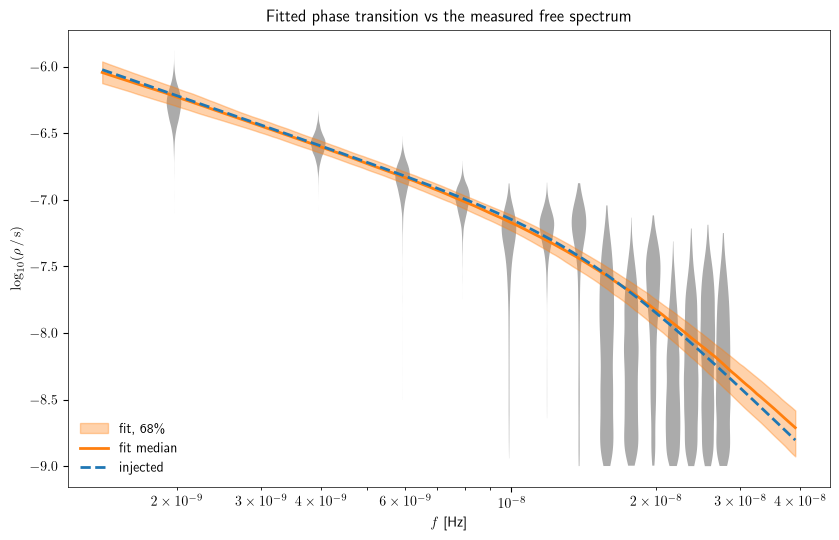

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

# One call draws all 14 free-spectrum posteriors.
rednoise.plot_free_spec(core, ax, "log10_rho", Tspan=Tspan, violin=True, Color="0.45")
ax.fill_between(f_plot, lo, hi, color="tab:orange", alpha=0.35, label="fit, 68\%")
ax.plot(f_plot, mid, color="tab:orange", lw=2, label="fit median")
ax.plot(f_plot, injected, color="tab:blue", lw=2, ls="--", label="injected")

ax.set_xscale("log")
ax.set_xlabel("$f$ [Hz]")
ax.set_ylabel(r"$\log_{10}(\rho\,/\,\mathrm{s})$")
ax.set_title("Fitted phase transition vs the measured free spectrum")
ax.legend(loc="lower left", frameon=False)
plt.tight_layout()

The lowest few bins are narrow and well measured, while the higher bins act as upper limits and are noise-dominated.

You've reached the end!

# Things to try

Each of these is a small edit to one of the two files you wrote, then a rerun.
Use a different `-n` so you don't overwrite this chain.

1. **Fix a parameter.** In the model file, replace the prior on `a` with
   `prior("Constant", 3)`. What happens to your posteriors?

2. **Fit the wrong model.** Write a second model file for a plain power law,
   $h^2\Omega = 10^{\log_{10}A}\,(f/f_{\rm yr})^{n}$, with uniform priors on
   $\log_{10}A$ and $n$. Fit the same data and compare.

3. **Use real data.** Set `pta_data = 'NG15'` and fit the actual NANOGrav 15 yr free
   spectrum. PTArcade downloads it for you. Do you get posteriors that matches the published paper?